# Data Preprocessing, Descriptive Analysis and Visualization
## Oluwafemi Gabriel James
### Applied Statistics

#### <b> Dataset Name:</b> Nutrition in Fast Food

<b> Description: </b>
Nutrition amounts in 515 fast food items.

<b> Format: </b>
A data frame with 515 observations on the following 17 variables.

- Restaurant: Name of restaurant
- Item: Name of item
- Calories: Number of calories
- Cal_fat: Calories from fat
- Total_fat: Total fat
- Sat_fat: Saturated fat
- Trans_fat: Trans fat
- Cholesterol: Cholesterol
- Sodium: Sodium
- Total_carb: Total carbs
- Fiber: Fiber
- Sugar: Suger
- Protein: Protein
- Vit_a: Vitamin A
- Vit_c: Vitamin C
- Calcium: Calcium
- Salad: Salad or not

<b>Source:</b> https://www.openintro.org/data/index.php?data=fastfood

In [2]:
# Load necessary packages for the analysis
library(ggplot2)
library(dplyr)
library(tidyr)
library(ggpubr)

In [3]:
# Reading and viewing the first few rows of the dataset in csv
fastfood <- read.csv("C:/Users/femij/Downloads/fastfood.csv")
head(fastfood)

,restaurant,item,calories,cal_fat,total_fat,sat_fat,trans_fat,cholesterol,sodium,total_carb,fiber,sugar,protein,vit_a,vit_c,calcium,salad
,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>
1,Mcdonalds,Artisan Grilled Chicken Sandwich,380,60,7,2,0.0,95,1110,44,3,11,37,4,20,20,Other
2,Mcdonalds,Single Bacon Smokehouse Burger,840,410,45,17,1.5,130,1580,62,2,18,46,6,20,20,Other
3,Mcdonalds,Double Bacon Smokehouse Burger,1130,600,67,27,3.0,220,1920,63,3,18,70,10,20,50,Other
4,Mcdonalds,Grilled Bacon Smokehouse Chicken Sandwich,750,280,31,10,0.5,155,1940,62,2,18,55,6,25,20,Other
5,Mcdonalds,Crispy Bacon Smokehouse Chicken Sandwich,920,410,45,12,0.5,120,1980,81,4,18,46,6,20,20,Other
6,Mcdonalds,Big Mac,540,250,28,10,1.0,80,950,46,3,9,25,10,2,15,Other


In [4]:
# Exploring the dataset structure
str(fastfood)

'data.frame':	515 obs. of  17 variables:
 $ restaurant : chr  "Mcdonalds" "Mcdonalds" "Mcdonalds" "Mcdonalds" ...
 $ item       : chr  "Artisan Grilled Chicken Sandwich" "Single Bacon Smokehouse Burger" "Double Bacon Smokehouse Burger" "Grilled Bacon Smokehouse Chicken Sandwich" ...
 $ calories   : int  380 840 1130 750 920 540 300 510 430 770 ...
 $ cal_fat    : int  60 410 600 280 410 250 100 210 190 400 ...
 $ total_fat  : int  7 45 67 31 45 28 12 24 21 45 ...
 $ sat_fat    : num  2 17 27 10 12 10 5 4 11 21 ...
 $ trans_fat  : num  0 1.5 3 0.5 0.5 1 0.5 0 1 2.5 ...
 $ cholesterol: int  95 130 220 155 120 80 40 65 85 175 ...
 $ sodium     : int  1110 1580 1920 1940 1980 950 680 1040 1040 1290 ...
 $ total_carb : int  44 62 63 62 81 46 33 49 35 42 ...
 $ fiber      : int  3 2 3 2 4 3 2 3 2 3 ...
 $ sugar      : int  11 18 18 18 18 9 7 6 7 10 ...
 $ protein    : int  37 46 70 55 46 25 15 25 25 51 ...
 $ vit_a      : int  4 6 10 6 6 10 10 0 20 20 ...
 $ vit_c      : int  20 20 20 25 20 

<b> Observation:</b>
This fastfood dataset contains: 
1. 515 observations of 17 variables, primarily detailing nutritional information (calories, fats, cholesterol, sodium, carbs, protein, vitamins, calcium) for various fast food items across different restaurants.
2. It includes categorical identifiers like restaurant, item, and a salad classification, alongside a comprehensive set of numerical nutrient metrics.

In [6]:
# Exploring the dataset description
summary(fastfood)

  restaurant            item              calories         cal_fat      
 Length:515         Length:515         Min.   :  20.0   Min.   :   0.0  
 Class :character   Class :character   1st Qu.: 330.0   1st Qu.: 120.0  
 Mode  :character   Mode  :character   Median : 490.0   Median : 210.0  
                                       Mean   : 530.9   Mean   : 238.8  
                                       3rd Qu.: 690.0   3rd Qu.: 310.0  
                                       Max.   :2430.0   Max.   :1270.0  
                                                                        
   total_fat         sat_fat         trans_fat      cholesterol    
 Min.   :  0.00   Min.   : 0.000   Min.   :0.000   Min.   :  0.00  
 1st Qu.: 14.00   1st Qu.: 4.000   1st Qu.:0.000   1st Qu.: 35.00  
 Median : 23.00   Median : 7.000   Median :0.000   Median : 60.00  
 Mean   : 26.59   Mean   : 8.153   Mean   :0.465   Mean   : 72.46  
 3rd Qu.: 35.00   3rd Qu.:11.000   3rd Qu.:1.000   3rd Qu.: 95.00  
 Max.   

<b> Observation: </b>
This output provides a detailed descriptive overview of the fastfood dataset, highlighting:
- Distribution of Nutritional Values: Most numerical variables (calories, fats, sodium, etc.) show a wide range of values and appear to be positively skewed (mean often greater than median), indicating that while many items might have moderate nutritional content, there are also numerous items with significantly higher values.
- Missing Data: A substantial number of missing values (NAs) are present, particularly for vit_a, vit_c, and calcium (over 200 missing each), and also for fiber and protein, which will require attention during any subsequent analysis.
- Categorical Identifiers: restaurant, item, and salad are confirmed as character/categorical variables, serving as identifiers or classifications rather than numerical measures.

### 1. Perform the following operations on the dataset

#### a. Quantitative data (Numeric Data)

In [7]:
# • Write a R code to drop the missing values in the quantitative dataset.
fastfood_clean <- na.omit(fastfood[sapply(fastfood, is.numeric)])

In [8]:
# • Print the first 15 rows of the dataset 
head(fastfood_clean, 15)

,calories,cal_fat,total_fat,sat_fat,trans_fat,cholesterol,sodium,total_carb,fiber,sugar,protein,vit_a,vit_c,calcium
,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,380,60,7,2,0.0,95,1110,44,3,11,37,4,20,20
2,840,410,45,17,1.5,130,1580,62,2,18,46,6,20,20
3,1130,600,67,27,3.0,220,1920,63,3,18,70,10,20,50
4,750,280,31,10,0.5,155,1940,62,2,18,55,6,25,20
5,920,410,45,12,0.5,120,1980,81,4,18,46,6,20,20
6,540,250,28,10,1.0,80,950,46,3,9,25,10,2,15
7,300,100,12,5,0.5,40,680,33,2,7,15,10,2,10
8,510,210,24,4,0.0,65,1040,49,3,6,25,0,4,2
9,430,190,21,11,1.0,85,1040,35,2,7,25,20,4,15


In [9]:
str(fastfood_clean)

'data.frame':	301 obs. of  14 variables:
 $ calories   : int  380 840 1130 750 920 540 300 510 430 770 ...
 $ cal_fat    : int  60 410 600 280 410 250 100 210 190 400 ...
 $ total_fat  : int  7 45 67 31 45 28 12 24 21 45 ...
 $ sat_fat    : num  2 17 27 10 12 10 5 4 11 21 ...
 $ trans_fat  : num  0 1.5 3 0.5 0.5 1 0.5 0 1 2.5 ...
 $ cholesterol: int  95 130 220 155 120 80 40 65 85 175 ...
 $ sodium     : int  1110 1580 1920 1940 1980 950 680 1040 1040 1290 ...
 $ total_carb : int  44 62 63 62 81 46 33 49 35 42 ...
 $ fiber      : int  3 2 3 2 4 3 2 3 2 3 ...
 $ sugar      : int  11 18 18 18 18 9 7 6 7 10 ...
 $ protein    : int  37 46 70 55 46 25 15 25 25 51 ...
 $ vit_a      : int  4 6 10 6 6 10 10 0 20 20 ...
 $ vit_c      : int  20 20 20 25 20 2 2 4 4 6 ...
 $ calcium    : int  20 20 50 20 20 15 10 2 15 20 ...
 - attr(*, "na.action")= 'omit' Named int [1:214] 60 70 77 78 83 84 112 113 115 116 ...
  ..- attr(*, "names")= chr [1:214] "60" "70" "77" "78" ...


In [10]:
nrow(fastfood) - nrow(fastfood_clean)

[1] 214

<b> Observation: </b>
1. Successfully removed 214 (Null Values) out of 515 observations from the dataset, leaving 301 rows for analysis. While this effectively handles missing values by creating a complete quantitative dataset, it's a significant reduction (over 41%) of your original data.
2. This substantial data loss could potentially impact the generalizability and representativeness of any subsequent statistical analysis, especially given that many of the missing values likely stemmed from the vit_a, vit_c, and calcium columns.

In [11]:
# • Find the 5 numbers summary, the IQR, and determine if there are outliers in your dataset (Dataset without NA values)
summary(fastfood_clean)

    calories       cal_fat         total_fat         sat_fat      
 Min.   :  20   Min.   :   0.0   Min.   :  0.00   Min.   : 0.000  
 1st Qu.: 340   1st Qu.: 120.0   1st Qu.: 13.00   1st Qu.: 4.000  
 Median : 490   Median : 200.0   Median : 22.00   Median : 7.000  
 Mean   : 537   Mean   : 229.5   Mean   : 25.55   Mean   : 7.849  
 3rd Qu.: 680   3rd Qu.: 310.0   3rd Qu.: 34.00   3rd Qu.:10.000  
 Max.   :2430   Max.   :1270.0   Max.   :141.00   Max.   :36.000  
   trans_fat       cholesterol         sodium       total_carb    
 Min.   :0.0000   Min.   :  0.00   Min.   :  15   Min.   :  0.00  
 1st Qu.:0.0000   1st Qu.: 40.00   1st Qu.: 830   1st Qu.: 30.00  
 Median :0.0000   Median : 65.00   Median :1120   Median : 44.00  
 Mean   :0.4551   Mean   : 75.23   Mean   :1274   Mean   : 47.53  
 3rd Qu.:1.0000   3rd Qu.: 95.00   3rd Qu.:1550   3rd Qu.: 61.00  
 Max.   :4.0000   Max.   :475.00   Max.   :6080   Max.   :156.00  
     fiber            sugar           protein           vit_a 

<b> Observation: </b>
- The summary(fastfood_clean) output confirms the successful elimination of all null values across the 14 quantitative variables. This na.omit() operation effectively transformed the dataset into a complete numerical matrix, ensuring that subsequent statistical computations will not be hampered by missing data points.
- While this ensures data integrity for direct analysis, the reduction from 515 to 301 observations (a 41.5% data loss) is a critical trade-off to consider for the generalizability and statistical power of any derived insights.

In [12]:
# • Write a R code to replace the missing values in your quantitative data frame with the mean.

fastfood_mean <- fastfood

# Replace NAs with column mean in all numeric columns
fastfood_mean[sapply(fastfood_mean, is.numeric)] <- lapply(
  fastfood_mean[sapply(fastfood_mean, is.numeric)],
  function(x) ifelse(is.na(x), mean(x, na.rm = TRUE), x)
)

In [13]:
# Double check if NA are gone
colSums(is.na(fastfood_mean))

restaurant        item    calories     cal_fat   total_fat     sat_fat 
          0           0           0           0           0           0 
  trans_fat cholesterol      sodium  total_carb       fiber       sugar 
          0           0           0           0           0           0 
    protein       vit_a       vit_c     calcium       salad 
          0           0           0           0           0

In [15]:
# Viewing the first 15 rows of the clean dataset using mean values
head(fastfood_mean, 15)

,restaurant,item,calories,cal_fat,total_fat,sat_fat,trans_fat,cholesterol,sodium,total_carb,fiber,sugar,protein,vit_a,vit_c,calcium,salad
,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<int>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,Mcdonalds,Artisan Grilled Chicken Sandwich,380,60,7,2,0.0,95,1110,44,3,11,37,4,20,20,Other
2,Mcdonalds,Single Bacon Smokehouse Burger,840,410,45,17,1.5,130,1580,62,2,18,46,6,20,20,Other
3,Mcdonalds,Double Bacon Smokehouse Burger,1130,600,67,27,3.0,220,1920,63,3,18,70,10,20,50,Other
4,Mcdonalds,Grilled Bacon Smokehouse Chicken Sandwich,750,280,31,10,0.5,155,1940,62,2,18,55,6,25,20,Other
5,Mcdonalds,Crispy Bacon Smokehouse Chicken Sandwich,920,410,45,12,0.5,120,1980,81,4,18,46,6,20,20,Other
6,Mcdonalds,Big Mac,540,250,28,10,1.0,80,950,46,3,9,25,10,2,15,Other
7,Mcdonalds,Cheeseburger,300,100,12,5,0.5,40,680,33,2,7,15,10,2,10,Other
8,Mcdonalds,Classic Chicken Sandwich,510,210,24,4,0.0,65,1040,49,3,6,25,0,4,2,Other
9,Mcdonalds,Double Cheeseburger,430,190,21,11,1.0,85,1040,35,2,7,25,20,4,15,Other


In [16]:
# Exlploring the dataset structure
str(fastfood_mean)

'data.frame':	515 obs. of  17 variables:
 $ restaurant : chr  "Mcdonalds" "Mcdonalds" "Mcdonalds" "Mcdonalds" ...
 $ item       : chr  "Artisan Grilled Chicken Sandwich" "Single Bacon Smokehouse Burger" "Double Bacon Smokehouse Burger" "Grilled Bacon Smokehouse Chicken Sandwich" ...
 $ calories   : int  380 840 1130 750 920 540 300 510 430 770 ...
 $ cal_fat    : int  60 410 600 280 410 250 100 210 190 400 ...
 $ total_fat  : int  7 45 67 31 45 28 12 24 21 45 ...
 $ sat_fat    : num  2 17 27 10 12 10 5 4 11 21 ...
 $ trans_fat  : num  0 1.5 3 0.5 0.5 1 0.5 0 1 2.5 ...
 $ cholesterol: int  95 130 220 155 120 80 40 65 85 175 ...
 $ sodium     : int  1110 1580 1920 1940 1980 950 680 1040 1040 1290 ...
 $ total_carb : int  44 62 63 62 81 46 33 49 35 42 ...
 $ fiber      : num  3 2 3 2 4 3 2 3 2 3 ...
 $ sugar      : int  11 18 18 18 18 9 7 6 7 10 ...
 $ protein    : num  37 46 70 55 46 25 15 25 25 51 ...
 $ vit_a      : num  4 6 10 6 6 10 10 0 20 20 ...
 $ vit_c      : num  20 20 20 25 20 

<b> Observation: </b>
1. Filled in all the empty spots (missing values) in the numeric columns of the fastfood_mean dataset by using the average value (mean) for each column. This is a good way to keep all 515 rows of your original data, so you don't lose any information, unlike when you just remove rows with missing data.
2. Replacing missing values with the mean can make the data look a little "too perfect." It makes the data less varied than it naturally is and might change how different variables relate to each other. This is especially true for columns like vit_a, vit_c, and calcium, which had a lot of missing data.

In [17]:
# • Find the 5 numbers summary, the IQR, and determine if there are outliers in your dataset (Dataset with Mean Values)
summary(fastfood_mean)

  restaurant            item              calories         cal_fat      
 Length:515         Length:515         Min.   :  20.0   Min.   :   0.0  
 Class :character   Class :character   1st Qu.: 330.0   1st Qu.: 120.0  
 Mode  :character   Mode  :character   Median : 490.0   Median : 210.0  
                                       Mean   : 530.9   Mean   : 238.8  
                                       3rd Qu.: 690.0   3rd Qu.: 310.0  
                                       Max.   :2430.0   Max.   :1270.0  
   total_fat         sat_fat         trans_fat      cholesterol    
 Min.   :  0.00   Min.   : 0.000   Min.   :0.000   Min.   :  0.00  
 1st Qu.: 14.00   1st Qu.: 4.000   1st Qu.:0.000   1st Qu.: 35.00  
 Median : 23.00   Median : 7.000   Median :0.000   Median : 60.00  
 Mean   : 26.59   Mean   : 8.153   Mean   :0.465   Mean   : 72.46  
 3rd Qu.: 35.00   3rd Qu.:11.000   3rd Qu.:1.000   3rd Qu.: 95.00  
 Max.   :141.00   Max.   :47.000   Max.   :8.000   Max.   :805.00  
     sodium  

<b> Obeservation: </b>
The 5-number summary for the quantitative variables in fastfood_mean reveals:

1. Wide Ranges: Most nutritional attributes (e.g., calories, total fat, sodium, sugar) exhibit a substantial range between their minimum and maximum values, indicating a broad spectrum of nutrient content across fast food items.
2. Right-Skewed Distributions: For many variables, the median is notably closer to the first quartile (Q1) than to the third quartile (Q3), and the maximum value is significantly further from Q3 than the minimum is from Q1. This pattern, coupled with the mean often being higher than the median, strongly suggests that their distributions are right-skewed, meaning there are a number of items with considerably higher nutrient values pulling the average upwards.
3. Impact of Mean Imputation: Specifically for vit_a, vit_c, and calcium, the 5-number summaries show a compression or clustering of the median and third quartile around the mean value. This is a direct consequence of the mean imputation strategy, where numerous missing values were replaced by the average, artificially reducing the spread and potentially altering the true distribution of these specific variables compared to their un-imputed state.

In [18]:
# Calculating the IQR, nd Outliers: a detailed summary with counts of low and high outliers
outlier_details <- lapply(
  fastfood_mean[sapply(fastfood_mean, is.numeric)],
  function(x) {
    q1 <- quantile(x, 0.25)
    q3 <- quantile(x, 0.75)
    iqr <- q3 - q1
    lower <- q1 - 1.5 * iqr
    upper <- q3 + 1.5 * iqr

    list(
      lower_outliers = sum(x < lower),
      upper_outliers = sum(x > upper),
      total_outliers = sum(x < lower | x > upper)
    )
  }
)

# View the outlier breakdown
outlier_details_df <- do.call(rbind, lapply(outlier_details, as.data.frame))
print(outlier_details_df)

            lower_outliers upper_outliers total_outliers
calories                 0              9              9
cal_fat                  0             21             21
total_fat                0             18             18
sat_fat                  0             24             24
trans_fat                0             14             14
cholesterol              0             23             23
sodium                   0             18             18
total_carb               0             15             15
fiber                    0             46             46
sugar                    0             14             14
protein                  0             12             12
vit_a                    0             35             35
vit_c                    0             70             70
calcium                  0             44             44


<b> Observations: </b>
1. All identified outliers are on the upper end of the distribution, meaning there are items with exceptionally high values for calories, fats, sodium, sugars, and protein, as well as vitamins and calcium. 
2. There are no low-end outliers.
3. Variables like vit_c (70 outliers), fiber (46 outliers), and calcium (44 outliers) show the highest counts of these unusually high values, suggesting a significant number of items with extreme nutritional profiles in the dataset.

### Represent your data using a suitable visualization method and describe your findings

#### Univariate Analysis (involving a single variable)

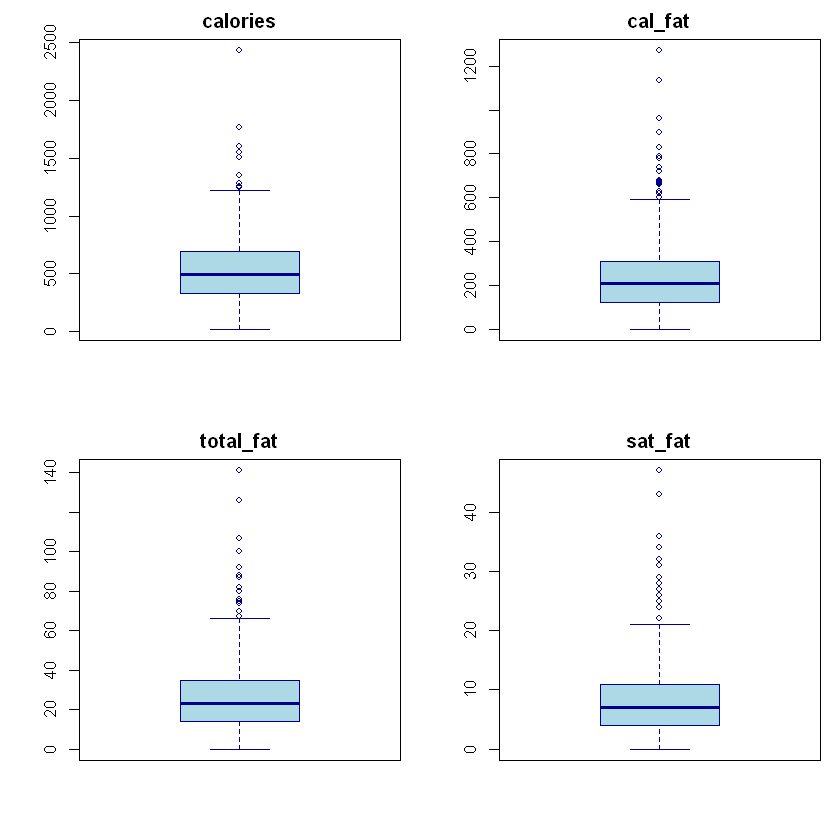

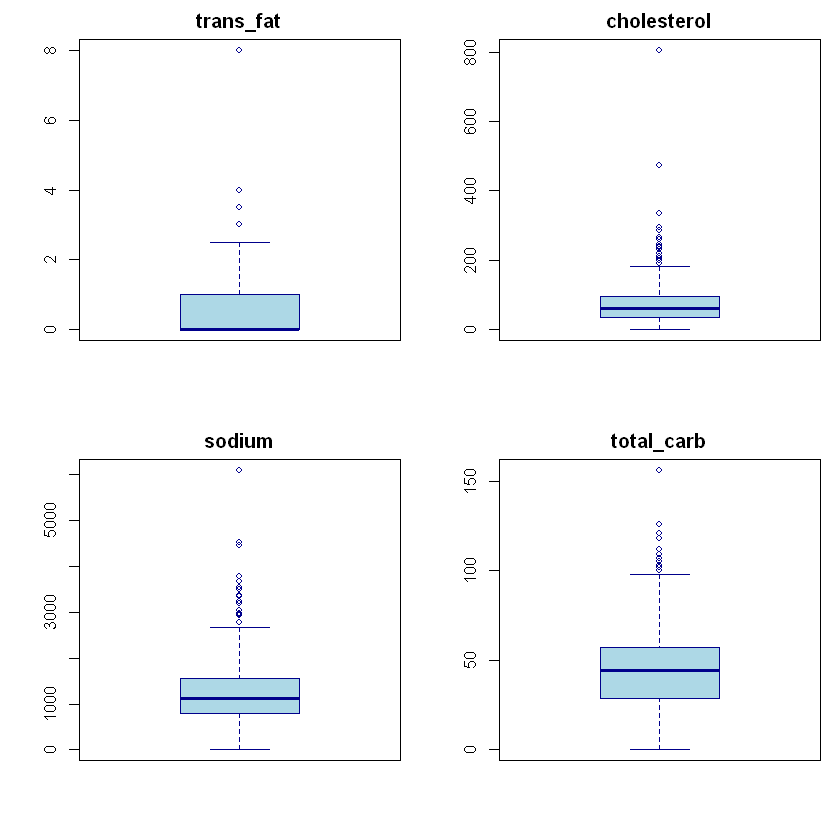

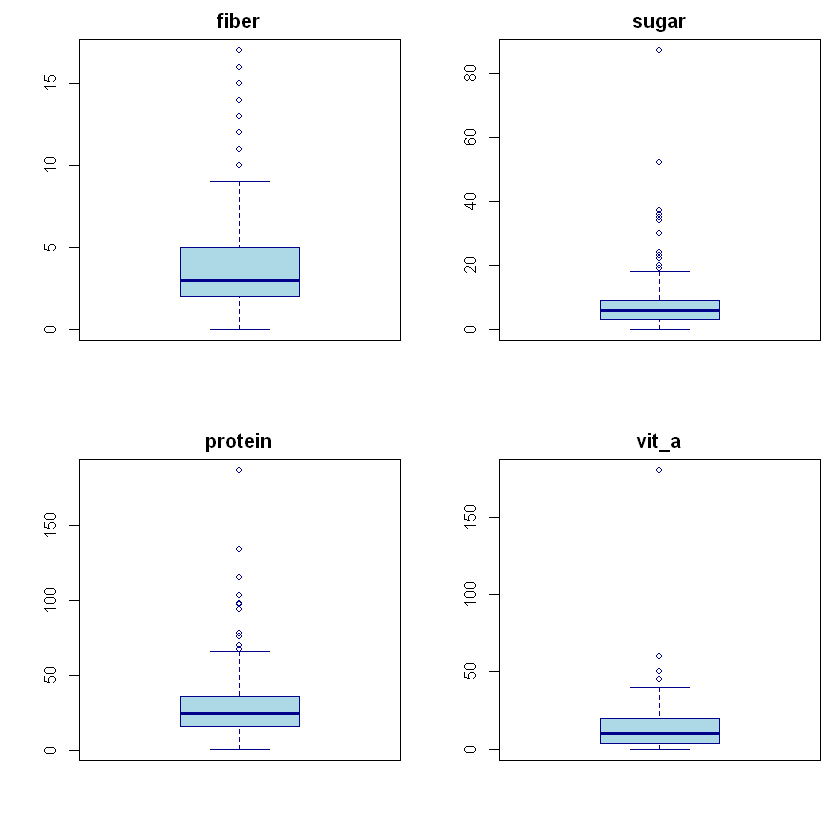

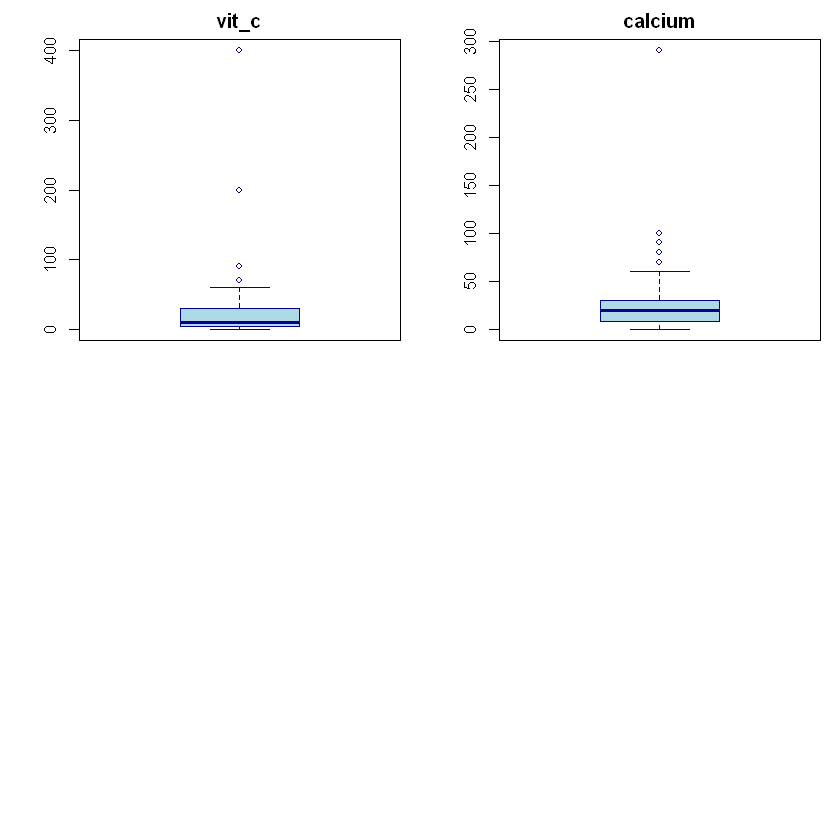

In [21]:
# Using a Box plot to Visualize the descriptive properties of all the quantitative variables in the data.

# Set up the plotting area
par(mfrow = c(2, 2), mar = c(4, 4, 2, 1))  # Adjusts margins

# Plot boxplots for all numeric columns
numeric_cols <- sapply(fastfood, is.numeric)
for (col in names(fastfood)[numeric_cols]) {
  boxplot(fastfood[[col]], 
          main = col, 
          col = "lightblue", 
          border = "darkblue",
          outline = TRUE)
}

<b> Observations: </b>
The box plots serve as a strong visual confirmation of the insights gathered from the 5-number summary and the outlier detection analysis for the fastfood_mean dataset.

These plots illustrate:
1. The skewed distributions of most nutritional variables, with the median (the line inside the box) consistently positioned closer to the bottom (Q1), and a visibly longer whisker extending upwards. This visually supports the calculated means being higher than the medians.
2. The prevalence of upper-end outliers, as evidenced by the numerous individual data points plotted far above the top whiskers. This directly reinforces our quantitative finding that many fast food items contain exceptionally high levels of various nutrients, confirming the presence and nature of the outliers identified by the IQR method.

In essence, the box plots provide a compelling graphical representation that underscores and validates the numerical properties observed in the dataset.

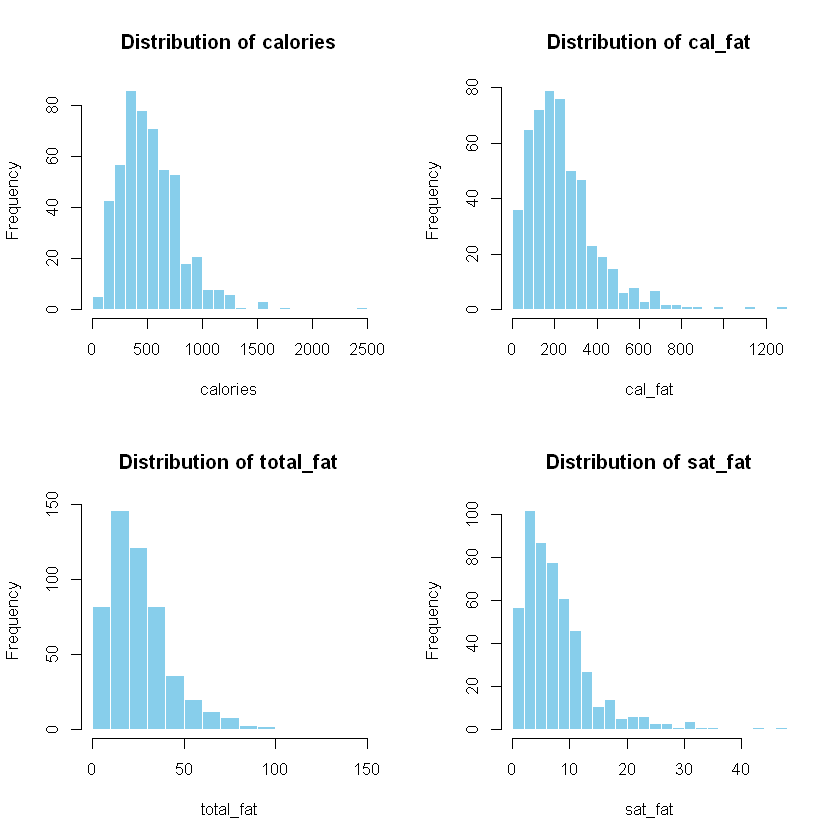

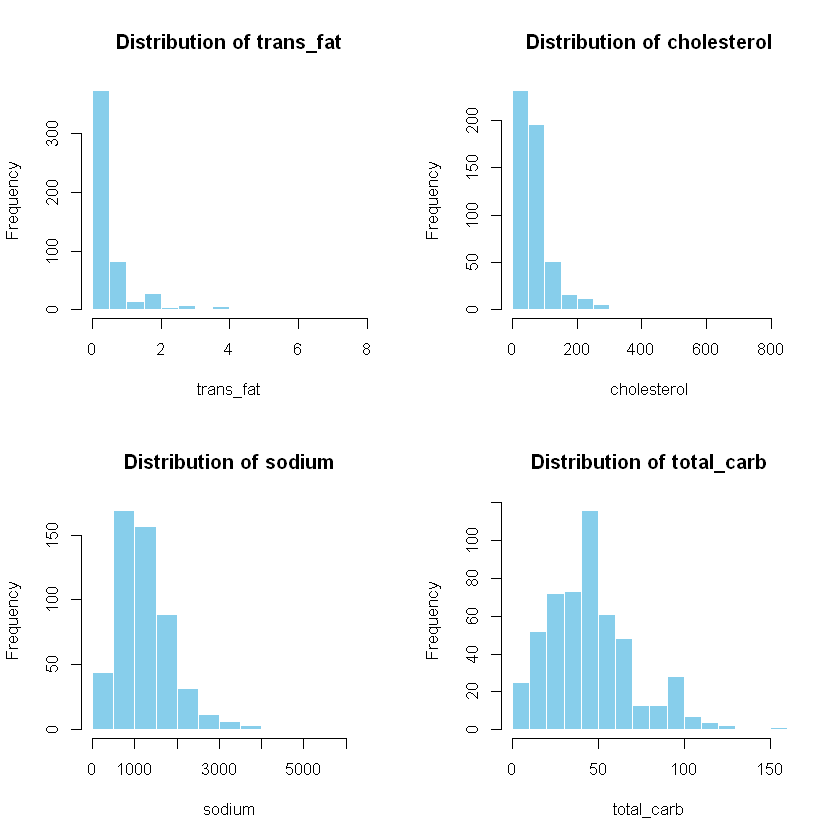

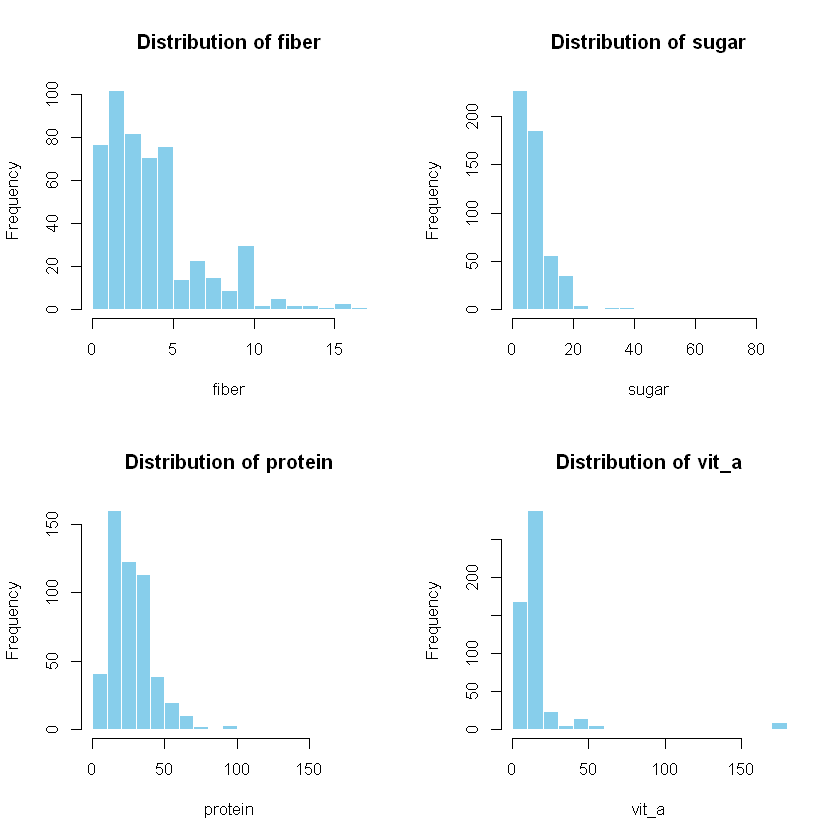

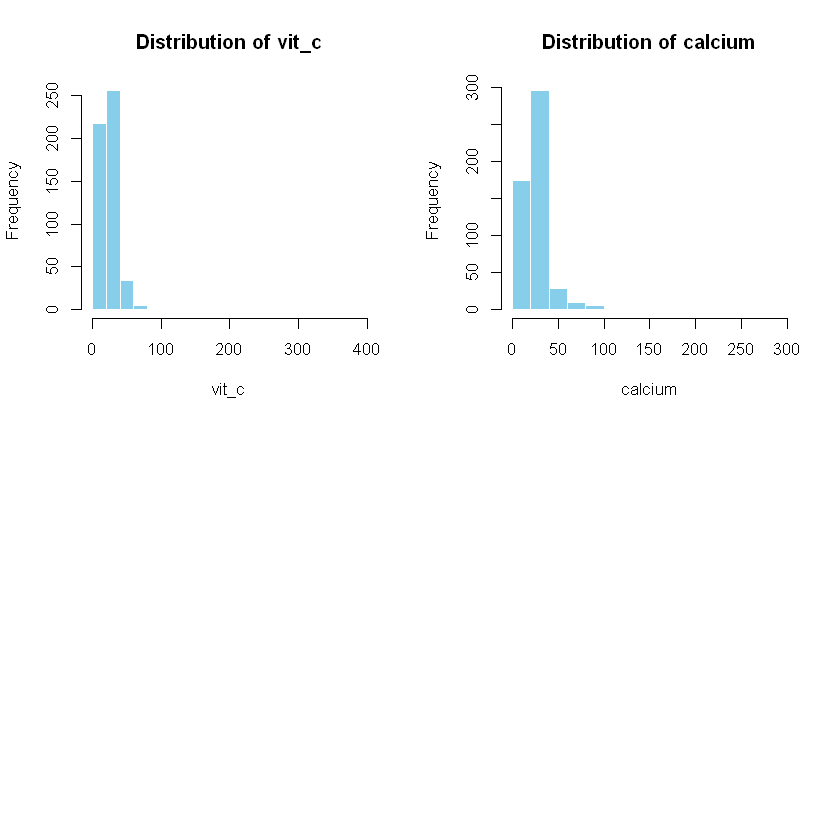

In [22]:
# Using a Histogram to visualize the frequency distribution of the numeric variables in the dataset

# Set up plotting area: 3 rows x 3 columns (adjust based on number of columns)
par(mfrow = c(2, 2))

# Loop through all numeric columns and plot histograms
numeric_cols <- sapply(fastfood_mean, is.numeric)

for (colname in names(fastfood_mean)[numeric_cols]) {
  hist(fastfood_mean[[colname]],
       breaks = 20,
       main = paste("Distribution of", colname),
       xlab = colname,
       col = "skyblue",
       border = "white")
}

# Reset plotting layout
par(mfrow = c(1, 1))

<b>Observation: </b> 
- The histograms visually confirm the right-skewed nature of most nutritional variables in fastfood_mean, showing frequencies concentrated at lower values with tails extending to higher ones. 
- For variables like vit_a, vit_c, and calcium, the histograms clearly reveal artificial peaks around their mean values, a direct visual consequence of the mean imputation technique. This illustrates the impact of imputation on data distribution, particularly where original missingness was high.

#### Bivariate Analysis (involving Two (2) variables)

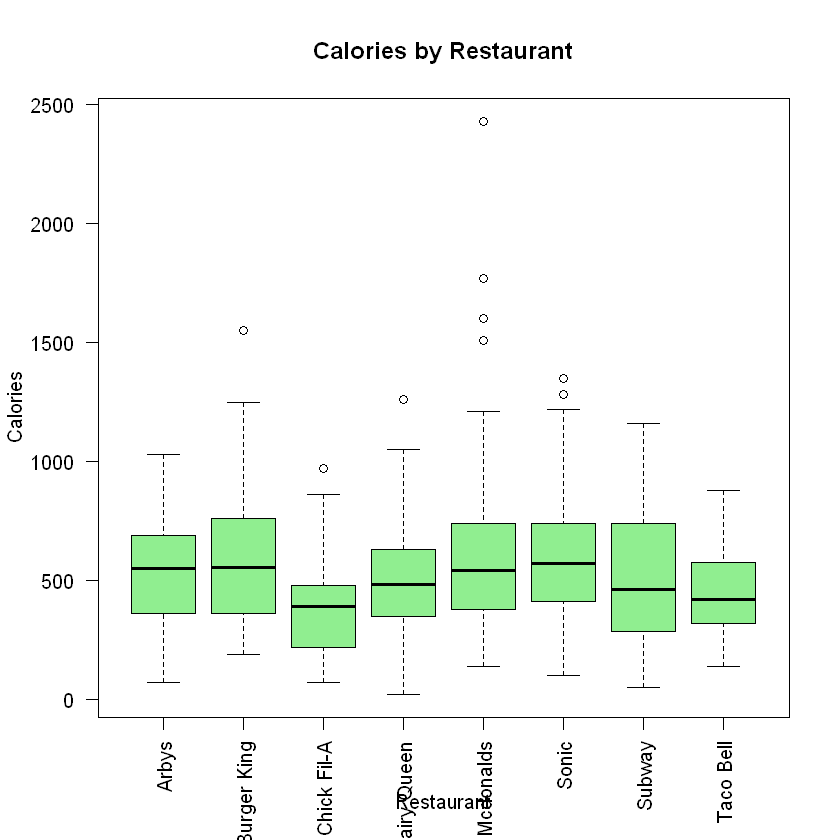

In [31]:
# Boxplots by Category: Compare calories across different restaurants.
boxplot(calories ~ restaurant, data = fastfood_mean,
        main = "Calories by Restaurant",
        xlab = "Restaurant",
        ylab = "Calories",
        col = "lightgreen", las = 2)

<b>Observation:</b>
Calories by Restaurant (Box Plot Observation)
1. The box plot of calories by restaurant demonstrates significant variation in caloric distribution across different fast-food chains. 
2. While outliers (exceptionally high-calorie items) are present in most restaurants, the visualization highlights differences in their median calorie offerings and overall range, indicating that the choice of restaurant influences the typical and extreme caloric content of a meal.

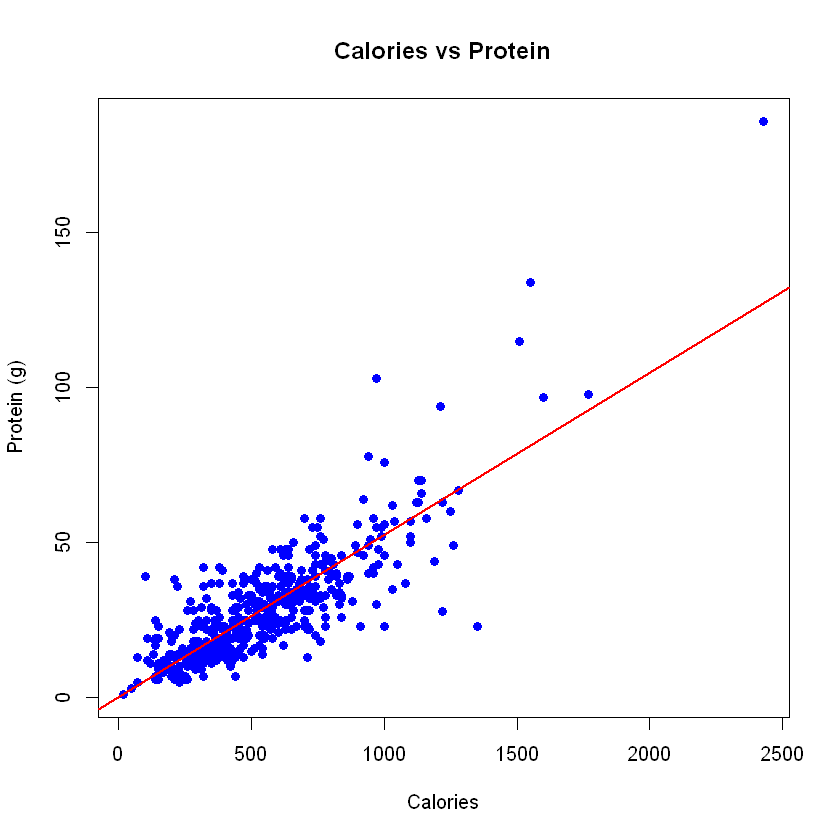

In [23]:
#Scatterplots with Regression Lines: Calories vs Protein
plot(fastfood_mean$calories, fastfood_mean$protein,
     main = "Calories vs Protein",
     xlab = "Calories",
     ylab = "Protein (g)",
     col = "blue", pch = 19)

# Add regression line
abline(lm(protein ~ calories, data = fastfood), col = "red", lwd = 2)

<b> Observation: </b>
Calories vs. Protein (Scatterplot Observation)
1. The scatterplot shows a clear positive relationship between calories and protein: as calorie content increases, protein generally increases too.
2. The regression line confirms this trend. However, there's still some variability, with items having similar calories showing different protein levels, and notable high-value outliers impacting the overall relationship.

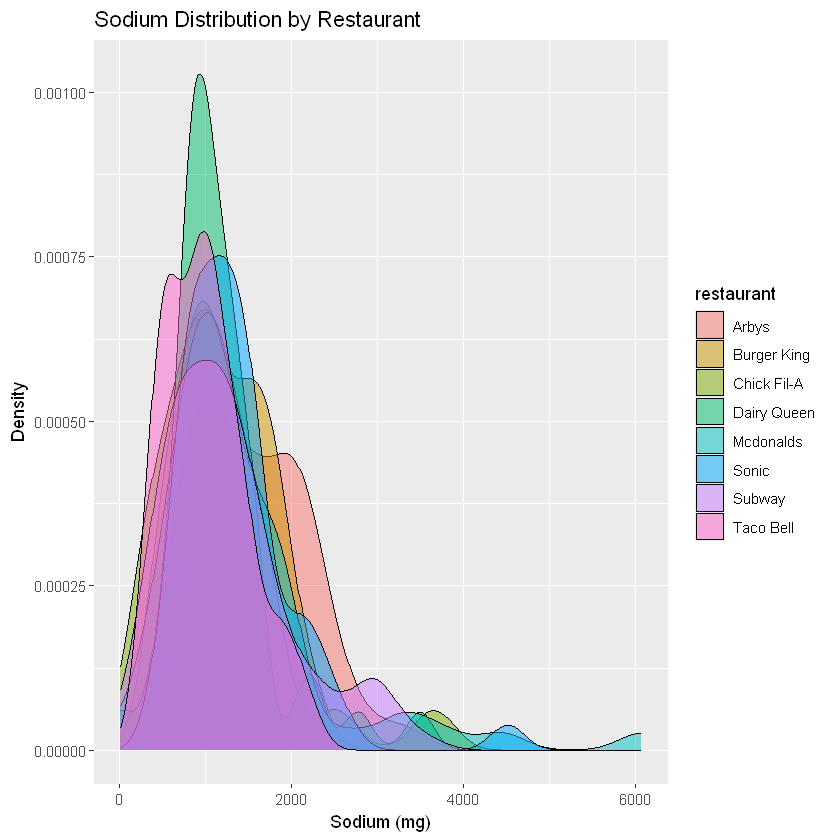

In [24]:
# Density Plots by Category: Compare the density of sodium for two or more restaurants
ggplot(fastfood_mean, aes(x = sodium, fill = restaurant)) +
  geom_density(alpha = 0.5) +
  labs(title = "Sodium Distribution by Restaurant",
       x = "Sodium (mg)", y = "Density")

<b> Observation: </b>
Sodium Distribution by Restaurant (Density Plot Observation)
1. The density plot comparing Sodium distribution by Restaurant visually illustrate the distinct patterns and overlaps in sodium content across different fast-food chains.
2. While each restaurant's sodium distribution exhibit a right-skewed shape (with more items having lower sodium and fewer items having very high sodium)

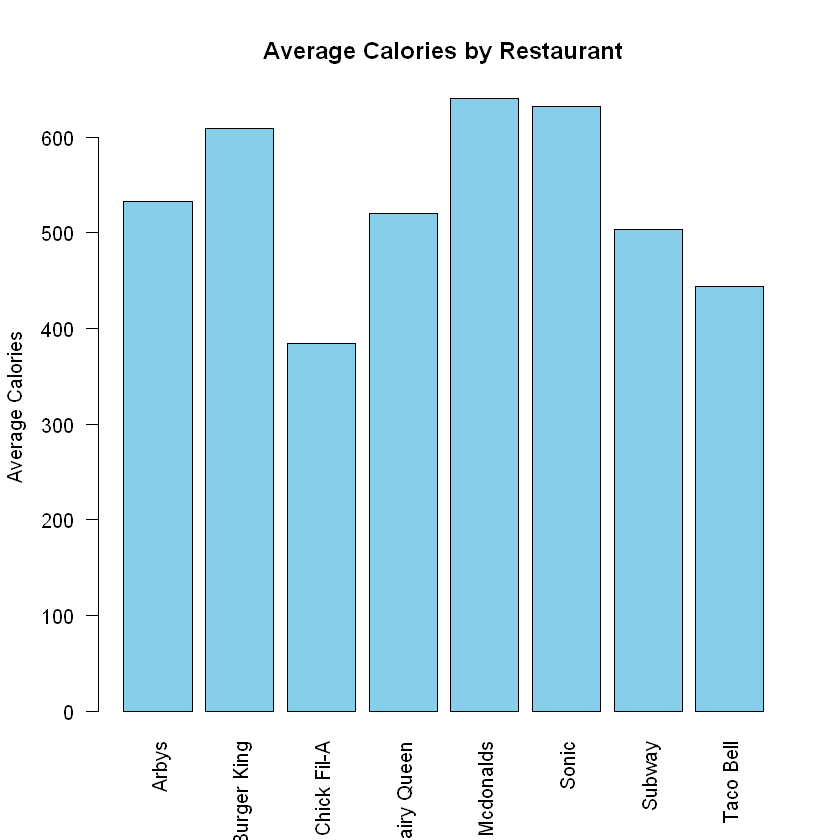

In [25]:
# Grouped Means Comparison (Bar Plot)

avg_calories <- fastfood_mean %>%
  group_by(restaurant) %>%
  summarise(mean_calories = mean(calories, na.rm = TRUE))

barplot(avg_calories$mean_calories,
        names.arg = avg_calories$restaurant,
        las = 2,
        col = "skyblue",
        main = "Average Calories by Restaurant",
        ylab = "Average Calories")

<b> Observation: </b> 
Average Calories by Restaurant (Bar Plot Observation)
1. This bar plot shows us the average number of calories you'll find in items at different fast-food restaurants. It makes it easy to see which restaurants generally offer higher or lower calorie meals.
2. In short, it tells us how the restaurant you choose affects the typical calorie count of the food.

#### Multi-variate Analysis (involving More than Two (2) variables)

In [26]:
# Correlation Matrix

# Prepare the Numeric Data: We’ll first isolate only numeric columns from your cleaned dataset.

# Extract only numeric columns
fastfood_numeric <- fastfood_mean[sapply(fastfood_mean, is.numeric)]

# Create correlation matrix
cor_matrix <- cor(fastfood_numeric)
print(round(cor_matrix, 2))  # Rounded for readability

            calories cal_fat total_fat sat_fat trans_fat cholesterol sodium
calories        1.00    0.90      0.90    0.74      0.53        0.76   0.82
cal_fat         0.90    1.00      1.00    0.85      0.65        0.80   0.67
total_fat       0.90    1.00      1.00    0.85      0.65        0.80   0.67
sat_fat         0.74    0.85      0.85    1.00      0.81        0.76   0.49
trans_fat       0.53    0.65      0.65    0.81      1.00        0.68   0.26
cholesterol     0.76    0.80      0.80    0.76      0.68        1.00   0.60
sodium          0.82    0.67      0.67    0.49      0.26        0.60   1.00
total_carb      0.71    0.42      0.42    0.28      0.10        0.24   0.67
fiber           0.28    0.03      0.04   -0.04     -0.12       -0.06   0.30
sugar           0.44    0.26      0.26    0.23      0.11        0.30   0.42
protein         0.83    0.71      0.71    0.60      0.47        0.87   0.77
vit_a          -0.12   -0.09     -0.09   -0.04     -0.06       -0.04  -0.11
vit_c       

<b> Observation: </b>
The correlation matrix reveals several key relationships among the numeric nutritional variables in the fastfood_mean dataset:

1. Strong Positive Correlations Among Major Macronutrients: There are very strong positive correlations (values generally above 0.70) among calories, cal_fat, total_fat, sat_fat, cholesterol, sodium, total_carb, and protein. This indicates that items high in one of these major nutritional components are typically high in the others as well. For example, calories is highly correlated with cal_fat (0.90), total_fat (0.90), sodium (0.82), and protein (0.83). Similarly, total_fat and cal_fat are almost perfectly correlated (1.00), as expected.

2. Moderate to Strong Positive Correlations with Trans Fat: trans_fat shows moderate to strong positive correlations with calories (0.53), cal_fat (0.65), total_fat (0.65), sat_fat (0.81), and cholesterol (0.68), suggesting that higher trans fat levels are generally associated with higher levels of other unhealthy fats and overall calories.

3. Weaker or Near-Zero Correlations for Vitamins/Minerals: vit_a, vit_c, and calcium generally show very weak or near-zero correlations with most other nutritional components, and even some small negative correlations (e.g., vit_a with calories at -0.12). This suggests that the presence or amount of these micronutrients is largely independent of the macronutrient content, which could also be partly influenced by the mean imputation applied to these variables.

4. Fiber and Sugar Relationships: fiber has a moderate positive correlation with total_carb (0.65) and a weaker one with sugar (0.23), as expected. sugar also shows moderate positive correlations with calories (0.44) and total_carb (0.55).

In summary, the matrix highlights strong interdependencies among the major energy and fat components, while vitamins and minerals appear to have largely independent relationships within the fast-food context.

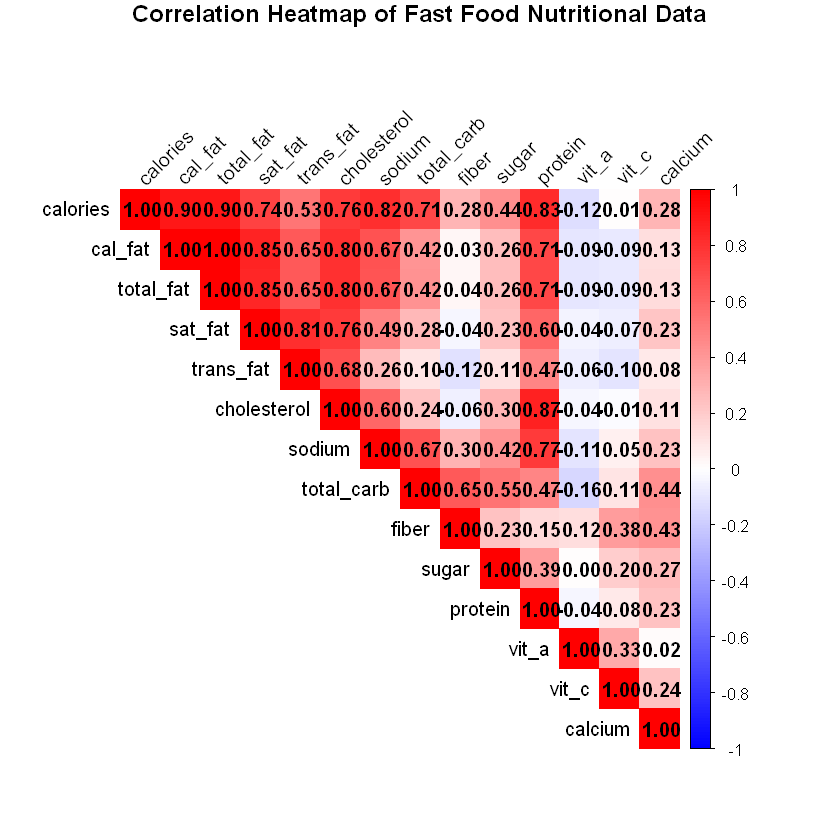

In [28]:
# Visualize with a Correlation Heatmap: We'll use the corrplot package for a clear visual.

# Install package
library(corrplot)

# Correlation plot
corrplot(cor_matrix, method = "color", type = "upper", 
         tl.col = "black", tl.srt = 45, addCoef.col = "black",
         col = colorRampPalette(c("blue", "white", "red"))(200),
         title = "Correlation Heatmap of Fast Food Nutritional Data",
         mar = c(0,0,1,0))

<b> Observation: </b>
Correlation Heatmap Observation
1. The heatmap visually confirms the strong positive correlations among macronutrients (e.g., calories, fats, protein) with deep red squares, showing they increase together. Conversely, vit_a, vit_c, and calcium display weak or near-zero correlations (white/light squares) with other nutrients, visually emphasizing their largely independent relationships within the fast food context.

### b. Qualitative data (Categorical Data)

In [34]:
# Write a R code to remove the rows with missing values 

# Extract only qualitative (non-numeric) data
fastfood_categorical <- fastfood[ , sapply(fastfood, Negate(is.numeric))]

In [35]:
# Remove rows with NA in the categorical data
fastfood_categorical_clean <- na.omit(fastfood_categorical)

In [36]:
# View cleaned data
head(fastfood_categorical_clean, 15)

,restaurant,item,salad
,<chr>,<chr>,<chr>
1,Mcdonalds,Artisan Grilled Chicken Sandwich,Other
2,Mcdonalds,Single Bacon Smokehouse Burger,Other
3,Mcdonalds,Double Bacon Smokehouse Burger,Other
4,Mcdonalds,Grilled Bacon Smokehouse Chicken Sandwich,Other
5,Mcdonalds,Crispy Bacon Smokehouse Chicken Sandwich,Other
6,Mcdonalds,Big Mac,Other
7,Mcdonalds,Cheeseburger,Other
8,Mcdonalds,Classic Chicken Sandwich,Other
9,Mcdonalds,Double Cheeseburger,Other


In [37]:
str(fastfood_categorical_clean)

'data.frame':	515 obs. of  3 variables:
 $ restaurant: chr  "Mcdonalds" "Mcdonalds" "Mcdonalds" "Mcdonalds" ...
 $ item      : chr  "Artisan Grilled Chicken Sandwich" "Single Bacon Smokehouse Burger" "Double Bacon Smokehouse Burger" "Grilled Bacon Smokehouse Chicken Sandwich" ...
 $ salad     : chr  "Other" "Other" "Other" "Other" ...


In [38]:
nrow(fastfood_categorical) - nrow(fastfood_categorical_clean)

[1] 0

<b> Observations: </b>
Missing Value Observation
1. The process of extracting and cleaning the categorical variables (restaurant, item, salad) confirms that there are no missing values in these columns.
2. After applying na.omit() to the fastfood_categorical dataset, the resulting fastfood_categorical_clean still retains all 515 original observations.
3. This ensures the completeness and integrity of the categorical data for direct use in analyses without any loss of records due to missingness.

In [39]:
summary(fastfood_categorical_clean)

  restaurant            item              salad          
 Length:515         Length:515         Length:515        
 Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character  

<b> Observations: </b>
1. The summary() output for fastfood_categorical_clean confirms that all three categorical variables—restaurant, item, and salad—are indeed of character class and mode. This means they contain text strings rather than numerical values, which is appropriate for their nature as identifiers or classifications.
2. With all three showing a Length:515, it further reinforces that these columns are complete with no missing values, making them ready for analyses like frequency counts or group comparisons.

In [40]:
# Write a R code to replace the missing values in your data frame with the mode.

# Function to compute the mode
get_mode <- function(x) {
  uniq_x <- unique(x[!is.na(x)])
  uniq_x[which.max(tabulate(match(x, uniq_x)))]
}

# Make a copy of the categorical data
fastfood_categorical_mode <- fastfood[ , sapply(fastfood, Negate(is.numeric))]

# Replace NAs in each categorical column with the mode
for (col in names(fastfood_categorical_mode)) {
  mode_val <- get_mode(fastfood_categorical_mode[[col]])
  fastfood_categorical_mode[[col]][is.na(fastfood_categorical_mode[[col]])] <- mode_val
}

# View result
head(fastfood_categorical_mode, 15)

,restaurant,item,salad
,<chr>,<chr>,<chr>
1,Mcdonalds,Artisan Grilled Chicken Sandwich,Other
2,Mcdonalds,Single Bacon Smokehouse Burger,Other
3,Mcdonalds,Double Bacon Smokehouse Burger,Other
4,Mcdonalds,Grilled Bacon Smokehouse Chicken Sandwich,Other
5,Mcdonalds,Crispy Bacon Smokehouse Chicken Sandwich,Other
6,Mcdonalds,Big Mac,Other
7,Mcdonalds,Cheeseburger,Other
8,Mcdonalds,Classic Chicken Sandwich,Other
9,Mcdonalds,Double Cheeseburger,Other


<b> Observations: </b>
1. The code successfully implements a mode imputation strategy for the categorical variables. However, based on our previous analysis, the categorical columns in the original fastfood dataset (and thus fastfood_categorical_mode before this operation) contained no missing values to begin with.

2. Therefore, while the R code is correctly structured to replace NAs with the mode, in this specific instance, no actual imputation was performed, as there were no missing values for the get_mode function to fill. The fastfood_categorical_mode dataset remains identical to its state before this imputation attempt, confirming the inherent completeness of the restaurant, item, and salad variables.

In [41]:
# Print the last 6 rows of the dataset 
tail(fastfood_categorical_mode, 6)

,restaurant,item,salad
,<chr>,<chr>,<chr>
510,Taco Bell,Original Triple Double Crunchwrap,Other
511,Taco Bell,Spicy Triple Double Crunchwrap,Other
512,Taco Bell,Express Taco Salad w/ Chips,Other
513,Taco Bell,Fiesta Taco Salad-Beef,Other
514,Taco Bell,Fiesta Taco Salad-Chicken,Other
515,Taco Bell,Fiesta Taco Salad-Steak,Other


In [ ]:
<b> Observations: </b>
Data Inspection: Last Rows Observation
The tail() function effectively displays the final 6 rows of the fastfood_categorical_mode dataset. This is a quick and useful way to confirm the structure and content of the data at its end, ensuring that the dataset is loaded completely and appears as expected after any preceding data manipulation.

### Represent your data using a suitable visualization method and describe your findings 

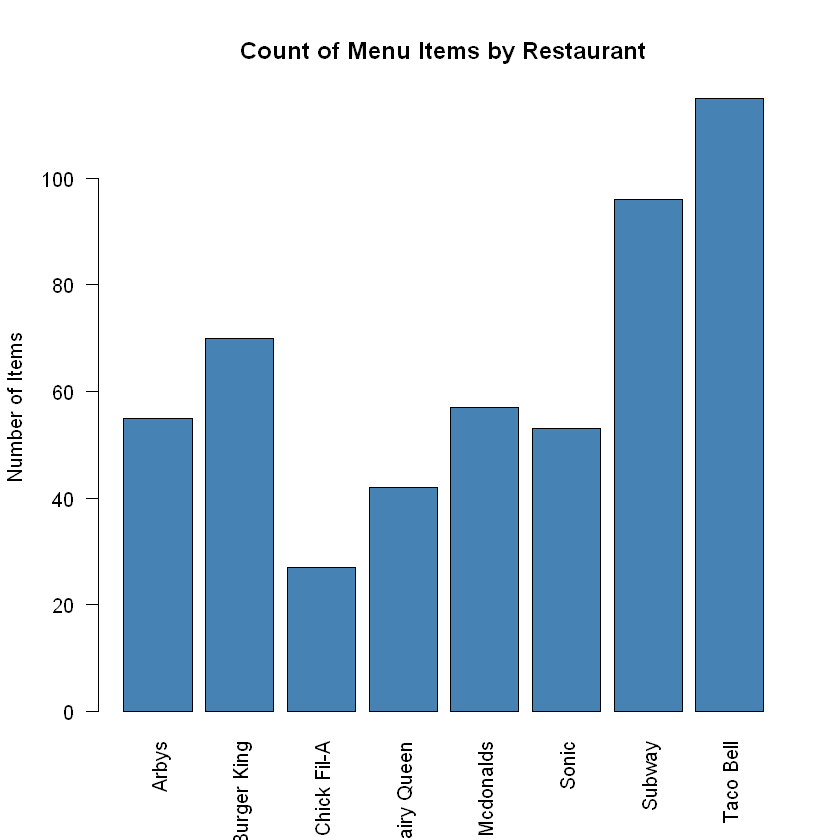

In [42]:
# Bar Plot of Restaurants
barplot(table(fastfood_categorical_mode$restaurant),
        col = "steelblue",
        main = "Count of Menu Items by Restaurant",
        ylab = "Number of Items",
        las = 2)

<b> Observations: </b>
Restaurant Item Counts (Bar Plot Observation)
1. The bar plot visualizing the "Count of Menu Items by Restaurant" clearly shows the distribution of fast food items across different restaurant chains within the dataset.
2. It highlights which restaurants have a larger representation of menu items in the data and which have fewer. This gives us a quick overview of the dataset's composition in terms of restaurant variety and the number of items sampled from each.

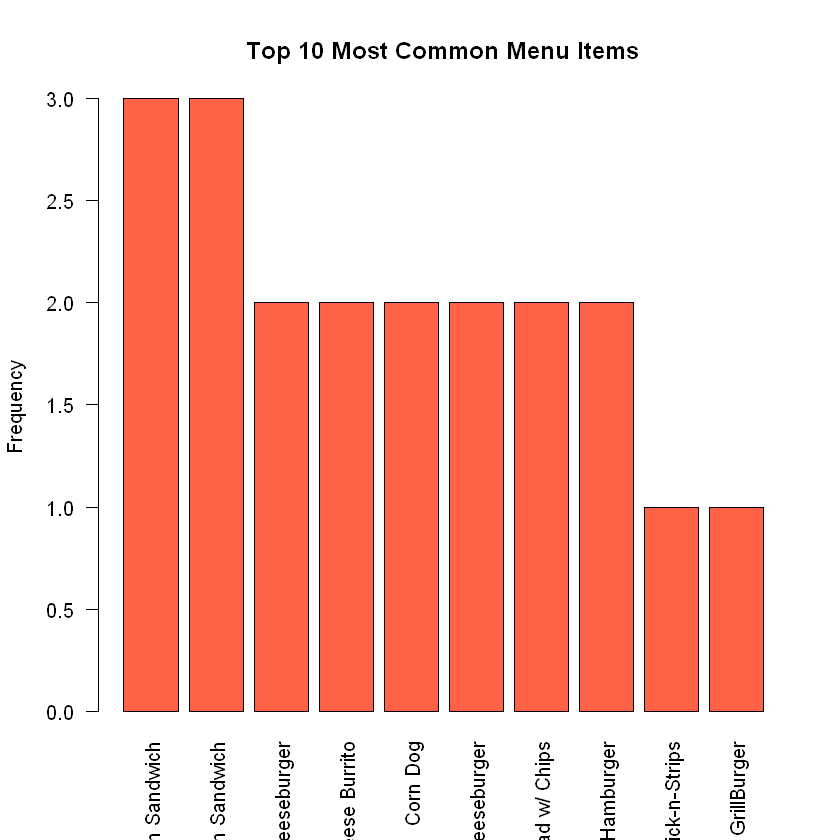

In [43]:
# Top 10 Most Common Menu Items (by frequency)

# Frequency table of items
item_freq <- sort(table(fastfood_categorical_mode$item), decreasing = TRUE)

# Barplot of top 10
barplot(item_freq[1:10],
        las = 2,
        col = "tomato",
        main = "Top 10 Most Common Menu Items",
        ylab = "Frequency")

<b> Observation: </b>
Top 10 Most Common Menu Items (Bar Plot Observation)
1. The bar plot of the "Top 10 Most Common Menu Items" provides a focused insight into the most frequently occurring individual food items within the dataset. This visualization distinctly highlights:

- Which specific menu items are repeatedly listed or appear most often, suggesting they might be standard offerings across different restaurant types or popular items with slight variations.
- The relative frequency of these top items, allowing for a quick comparison of their prevalence.

This plot is useful for understanding the dataset's emphasis on particular items, rather than broad restaurant categories.

#### c. Demonstrate your understanding of filter to separate category either with your qualitative or quantitative data using an R code

In [44]:
# 1. Filtering Qualitative (Categorical) Data Example

# for only items from "Mcdonalds":
mcdonalds_items <- fastfood %>%
  filter(restaurant == "Mcdonalds")

head(mcdonalds_items)  # View first few rows

,restaurant,item,calories,cal_fat,total_fat,sat_fat,trans_fat,cholesterol,sodium,total_carb,fiber,sugar,protein,vit_a,vit_c,calcium,salad
,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>
1,Mcdonalds,Artisan Grilled Chicken Sandwich,380,60,7,2,0.0,95,1110,44,3,11,37,4,20,20,Other
2,Mcdonalds,Single Bacon Smokehouse Burger,840,410,45,17,1.5,130,1580,62,2,18,46,6,20,20,Other
3,Mcdonalds,Double Bacon Smokehouse Burger,1130,600,67,27,3.0,220,1920,63,3,18,70,10,20,50,Other
4,Mcdonalds,Grilled Bacon Smokehouse Chicken Sandwich,750,280,31,10,0.5,155,1940,62,2,18,55,6,25,20,Other
5,Mcdonalds,Crispy Bacon Smokehouse Chicken Sandwich,920,410,45,12,0.5,120,1980,81,4,18,46,6,20,20,Other
6,Mcdonalds,Big Mac,540,250,28,10,1.0,80,950,46,3,9,25,10,2,15,Other


<b> Observations: </b> 
Filtering Qualitative Data: "Mcdonalds" Items Observation
1. The R code successfully demonstrates the use of the filter() function to subset the fastfood dataset, retaining only the observations where the restaurant variable is "Mcdonalds".
2. The resulting mcdonalds_items data frame exclusively contains entries from this specific restaurant, as confirmed by the head() output. This showcases an effective method for isolating categorical data based on a specific criterion, allowing for focused analysis on a particular subset of interest.

In [45]:
# Filtering Quantitative (Numeric) Data Example

# filter for items that have calories greater than 800:

high_calorie_items <- fastfood %>%
  filter(calories > 800)

head(high_calorie_items)

,restaurant,item,calories,cal_fat,total_fat,sat_fat,trans_fat,cholesterol,sodium,total_carb,fiber,sugar,protein,vit_a,vit_c,calcium,salad
,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>
1,Mcdonalds,Single Bacon Smokehouse Burger,840,410,45,17,1.5,130,1580,62,2,18,46,6,20,20,Other
2,Mcdonalds,Double Bacon Smokehouse Burger,1130,600,67,27,3.0,220,1920,63,3,18,70,10,20,50,Other
3,Mcdonalds,Crispy Bacon Smokehouse Chicken Sandwich,920,410,45,12,0.5,120,1980,81,4,18,46,6,20,20,Other
4,Mcdonalds,10 piece Buttermilk Crispy Chicken Tenders,1210,630,70,12,1.0,240,3230,52,1,4,94,0,0,4,Other
5,Mcdonalds,12 piece Buttermilk Crispy Chicken Tenders,1510,790,88,15,1.0,295,3770,64,1,2,115,0,2,6,Other
6,Mcdonalds,20 piece Buttermilk Crispy Chicken Tenders,2430,1270,141,24,2.0,475,6080,103,2,3,186,0,2,8,Other


<b> Observations: </b>
Filtering Quantitative Data: High-Calorie Items Observation
1. The R code demonstrates the use of the filter() function to subset the fastfood dataset based on a quantitative condition, specifically isolating observations where calories are greater than 800.
2. The resulting high_calorie_items data frame exclusively contains entries meeting this nutritional criterion, as confirmed by the head() output. This showcases a powerful method for focusing analysis on specific segments of quantitative data, such as high-energy food options.

In [46]:
# Combine Both Quantitative and Qualitative Filters

# Filter items from Burger King with sodium under 1000 mg:

bk_low_sodium <- fastfood %>%
  filter(restaurant == "Burger King", sodium < 1000)

head(bk_low_sodium)

,restaurant,item,calories,cal_fat,total_fat,sat_fat,trans_fat,cholesterol,sodium,total_carb,fiber,sugar,protein,vit_a,vit_c,calcium,salad
,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>
1,Burger King,Bacon Cheeseburger,330,140,16,7,0.0,55,830,32,1,7,18,NA,NA,NA,Other
2,Burger King,Bacon Cheeseburger Deluxe,290,120,14,6,0.5,40,720,28,1,7,12,NA,NA,NA,Other
3,Burger King,Cheeseburger,300,130,14,6,0.0,45,710,28,1,6,16,NA,NA,NA,Other
4,Burger King,Double Cheeseburger,450,230,26,12,1.0,95,960,29,1,6,26,NA,NA,NA,Other
5,Burger King,Double Hamburger,360,160,18,8,0.0,70,520,28,1,6,22,NA,NA,NA,Other
6,Burger King,Hamburger,260,90,10,4,0.0,35,490,28,1,6,13,NA,NA,NA,Other


<b> Observations: </b>
Combined Filtering Observation: "Burger King" Low Sodium Items
1. This code demonstrates the power of filter() to apply multiple criteria simultaneously for more specific data subsetting. By combining a qualitative condition (restaurant == "Burger King") with a quantitative condition (sodium < 1000), the bk_low_sodium data frame effectively isolates only those menu items from Burger King that also have less than 1000 mg of sodium.
2. This highlights how filters can be chained to precisely narrow down the dataset to highly specific areas of interest for targeted analysis.